<a href="https://colab.research.google.com/github/DatDereDaag/COMP-3610-Assignment-1/blob/main/816039536_COMP3608_A1_2025_2026_Question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Submission details
ID#: 816039536    \
Name:   Arvesh Gosine

## MyElearning submission
- Upload notebook to myelearning submission \
- Submit link to colabnotebook in the submission textbok

#Question 2

Solve Question 1 using gradient descent. Your solution should be within 0.2 of its optimal $β_0$ and $β_1$. **[20 marks]**

Our final values of β0 and β1 are:
β0: -0.5740
β1: 0.7954
The final minimum loss(deviation) was: 1.6127


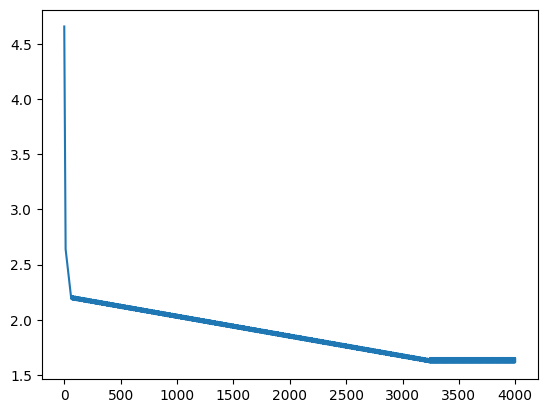

In [ ]:
import matplotlib.pyplot as plt
import torch as th
import torch.optim as optim
import torch.nn as nn
import numpy as np

# Helper function to plot the loss curve
def plot_loss_curve(loss_curve):
  plt.plot(list(range(len(loss_curve))), loss_curve)

#Our data for the 4 observations convertd to tensors for calculation
power = th.tensor([1., 3., 3., 5.])
level = th.tensor([2., 3., 5., 7.])

def loss_function(b0, b1):

  #Calculate the prediction using the tensors for b0,b1 and the level
  predictions = b0 + b1*level

  #Calculate the deviation using the tensor for the power and the prediction
  deviation = power - predictions

  return th.sum(th.abs(deviation))


#The model we use to optimize b0 and b1
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()
    b0 = th.tensor(np.random.random())
    b1 = th.tensor(np.random.random())
    self.b0 = nn.Parameter(b0)
    self.b1 = nn.Parameter(b1)

  def loss(self):
    return loss_function(self.b0, self.b1)


model = MyModel()
lr = 0.001 #Learning rate is very low to prevent large spikes in learning, no penalty function possible without constraints
loss_curve = []
optimizer = optim.SGD(model.parameters(), lr=lr)
num_epochs = 4000 #The model learns at a slow rate so many iterations needed to get optimal value accurately

min_loss = None

for epoch in range(num_epochs):
  optimizer.zero_grad() #Zero out the gradients from previous calc
  loss = model.loss() #Calculate the loss function
  loss.backward() #Caclulate the gradient of this function

  loss_curve.append(loss.item()) #Add to the loss curve for visualization

  if min_loss is None or loss.item() < min_loss:
      min_loss = loss.item()

  optimizer.step() #Update the parameters

print("Our final values of β0 and β1 are:")
print(f"β0: {model.b0.data:.4f}")
print(f"β1: {model.b1.data:.4f}")
print(f"The final minimum loss(deviation) was: {min_loss:.4f}")
plot_loss_curve(loss_curve)


